# Анализ лояльности пользователей Яндекс Афиши

## Введение

Цель проекта — понять, какие пользователи чаще возвращаются на платформу и делают повторные заказы. Для этого я:
- выгружу данные из БД и выполню предобработку;
- построю профиль пользователей и рассчитаю метрики лояльности;
- исследую факторы первого заказа, выручки, состава заказа и времени;
- проверю гипотезы и подготовлю рекомендации для маркетинга.

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Параметры подключения храните в `.env` (не в коде). В тетрадке используйте переменные окружения и `SQLAlchemy`.

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# При необходимости добавляйте новые ячейки для кода или текста

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from dotenv import load_dotenv

sns.set(style="whitegrid")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_NAME = os.getenv("DB_NAME")
DB_PORT = os.getenv("DB_PORT")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [4]:
db_config = {
    "user": DB_USER,
    "pwd": DB_PASSWORD,
    "host": DB_HOST,
    "port": DB_PORT,
    "db": DB_NAME,
}

connection_string = "postgresql+psycopg2://{}:{}@{}:{}/{}".format(
    db_config["user"],
    db_config["pwd"],
    db_config["host"],
    db_config["port"],
    db_config["db"],
)

engine = create_engine(connection_string)

# SQL-запрос из прошлого урока (выгрузка данных для анализа)
SQL_QUERY = """
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    CASE
        WHEN LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk) IS NULL
            THEN NULL
        ELSE p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)
    END AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
JOIN afisha.events AS e ON p.event_id = e.event_id
JOIN afisha.city AS c ON e.city_id = c.city_id
JOIN afisha.regions AS r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main <> 'film'
"""

df = pd.read_sql_query(SQL_QUERY, con=engine)

df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaT,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaT,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75 days,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaT,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83 days,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк


In [5]:
display(df.sample(5, random_state=42))

print("Размер выборки:", df.shape)

# Общая информация
info = df.info()

# Объем памяти
mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Объем памяти: {mem_mb:.2f} МБ")

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name
210088,af26d5b5924d2f3,mobile,1029501,2024-10-11,2024-10-11 13:09:46,rub,52.33,3,0 days,384539,9df5333c-9d3a-4d97-aafb-958e6e22204b,Билеты без проблем,другое,Речицкий регион,Глинянск
3001,02812f1183de24c,desktop,671757,2024-10-01,2024-10-01 11:14:49,rub,77.99,2,0 days,574431,d4344522-b7cf-4539-96c8-efece75e9b16,Билеты в руки,спорт,Медовская область,Радужсвет
190502,9e01e5222f47f8c,desktop,5924904,2024-07-22,2024-07-22 22:57:16,rub,236.32,3,NaT,365092,8f845fdc-cc5c-43b4-8da6-5a0996bc818e,Билеты без проблем,выставки,Североярская область,Озёрск
96697,4678368531a1efd,mobile,5081381,2024-06-08,2024-06-08 19:39:27,rub,686.87,2,0 days,518819,d695fe57-a36c-4aba-8f3c-439e88709d49,Билеты без проблем,концерты,Каменевский регион,Глиногорск
16412,0beb8fc0c0a9ce1,mobile,3284628,2024-07-09,2024-07-09 17:35:07,rub,47.85,4,0 days,501198,75f20014-54dd-4cb5-ad6e-8ceeed4fc324,Билеты в руки,другое,Заречная область,Дальнесветин


Размер выборки: (290849, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype          
---  ------                 --------------   -----          
 0   user_id                290849 non-null  object         
 1   device_type_canonical  290849 non-null  object         
 2   order_id               290849 non-null  int64          
 3   order_dt               290849 non-null  datetime64[ns] 
 4   order_ts               290849 non-null  datetime64[ns] 
 5   currency_code          290849 non-null  object         
 6   revenue                290849 non-null  float64        
 7   tickets_count          290849 non-null  int64          
 8   days_since_prev        268909 non-null  timedelta64[ns]
 9   event_id               290849 non-null  int64          
 10  event_name             290849 non-null  object         
 11  service_name           290849 non-null  object         
 12  e

Объем памяти: 212.38 МБ


Промежуточный вывод: данные успешно выгружены, в выборке представлены заказы пользователей с основными атрибутами заказа и события.
На следующем шаге потребуется привести типы данных (даты и числовые поля) и проверить пропуски и аномалии, а также привести выручку к рублям.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [6]:
tenge_url = "https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv"
tenge_df = pd.read_csv(tenge_url)

# Приведем даты к единому формату

df["order_dt"] = pd.to_datetime(df["order_dt"], errors="coerce")
df["order_ts"] = pd.to_datetime(df["order_ts"], errors="coerce")

tenge_df["data"] = pd.to_datetime(tenge_df["data"], errors="coerce")

# Переименуем для наглядности

tenge_df = tenge_df.rename(columns={"data": "order_dt", "curs": "rub_per_100_tenge"})

# Джойним курс по дате заказа

merged = df.merge(tenge_df[["order_dt", "rub_per_100_tenge", "nominal"]], on="order_dt", how="left")

# Перевод выручки в рубли

merged["revenue_rub"] = np.where(
    merged["currency_code"] == "RUB",
    merged["revenue"],
    merged["revenue"] * (merged["rub_per_100_tenge"] / merged["nominal"])
)

df = merged.copy()

df[["currency_code", "revenue", "revenue_rub"]].head()

,currency_code,revenue,revenue_rub
0,rub,1521.94,284.560166
1,rub,289.45,53.090630
2,rub,1258.57,247.277541
3,rub,8.49,1.570735
4,rub,1390.41,273.421346


In [7]:
print("Доля заказов без курса:", df["rub_per_100_tenge"].isna().mean().round(4))

# Проверим базовые статистики по новой выручке

df["revenue_rub"].describe().to_frame()

Доля заказов без курса: 0.0


,revenue_rub
count,290849.000000
mean,120.206549
std,238.396231
min,-18.190936
25%,22.461117
50%,67.974468
75%,155.428717
max,15520.734397


Промежуточный вывод: добавлен столбец `revenue_rub`, выручка приведена к рублям по курсу тенге на дату заказа.
Если есть пропуски по курсу, их нужно проверить отдельно (например, при несовпадении дат) и при необходимости скорректировать.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [8]:
# Пропуски
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0].to_frame("missing_share")

# Приведение типов

df["tickets_count"] = pd.to_numeric(df["tickets_count"], errors="coerce")
df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")
df["revenue_rub"] = pd.to_numeric(df["revenue_rub"], errors="coerce")

if pd.api.types.is_timedelta64_dtype(df["days_since_prev"]):
    df["days_since_prev"] = df["days_since_prev"].dt.days
else:
    df["days_since_prev"] = pd.to_numeric(df["days_since_prev"], errors="coerce")

# Дни между покупками не могут быть отрицательными
# Иногда пропуски могут приходить как минимальное значение int
invalid_days = (df["days_since_prev"] < 0) | (df["days_since_prev"] == np.iinfo("int64").min)
df.loc[invalid_days, "days_since_prev"] = np.nan

# Оптимизация типов идентификаторов

id_cols = ["user_id", "order_id", "event_id"]
for col in id_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce", downcast="integer")

# Нормализация категориальных значений

cat_cols = [
    "device_type_canonical",
    "currency_code",
    "service_name",
    "event_type_main",
    "region_name",
    "city_name",
]
for col in cat_cols:
    df[col] = df[col].astype("string").str.strip()

# Проверим уникальные значения в ключевых столбцах

{col: df[col].nunique() for col in cat_cols}

{'device_type_canonical': 2,
 'currency_code': 2,
 'service_name': 36,
 'event_type_main': 8,
 'region_name': 81,
 'city_name': 352}

Доля отфильтрованных заказов: 0.0100
p99 revenue_rub: 761.63


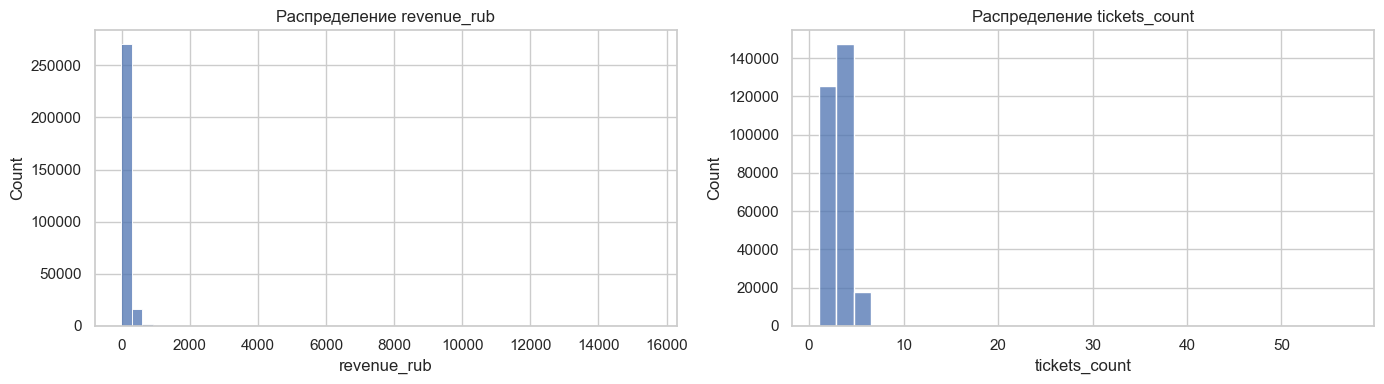

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["revenue_rub"], bins=50, ax=axes[0])
axes[0].set_title("Распределение revenue_rub")

sns.histplot(df["tickets_count"], bins=30, ax=axes[1])
axes[1].set_title("Распределение tickets_count")

plt.tight_layout()

# Фильтрация выбросов по 99-му перцентилю выручки
p99 = df["revenue_rub"].quantile(0.99)

df_clean = df[df["revenue_rub"] <= p99].copy()

filtered_share = 1 - (len(df_clean) / len(df))
print(f"Доля отфильтрованных заказов: {filtered_share:.4f}")
print("p99 revenue_rub:", round(p99, 2))

Промежуточный вывод: приведены типы данных, нормализованы категории, проверены пропуски.
Выручка очищена от выбросов по 99-му перцентилю; доля удалённых значений зафиксирована.
Для дальнейшего анализа используем `df_clean`.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [10]:
df_clean = df_clean.sort_values("order_ts")

first_orders = (
    df_clean
    .sort_values("order_ts")
    .groupby("user_id")
    .first()
    .reset_index()
)

agg = df_clean.groupby("user_id").agg(
    first_order_dt=("order_dt", "min"),
    last_order_dt=("order_dt", "max"),
    total_orders=("order_id", "nunique"),
    avg_revenue_rub=("revenue_rub", "mean"),
    avg_tickets_count=("tickets_count", "mean"),
    avg_days_between=("days_since_prev", "mean"),
).reset_index()

user_profile = agg.merge(
    first_orders[[
        "user_id",
        "device_type_canonical",
        "region_name",
        "service_name",
        "event_type_main",
    ]],
    on="user_id",
    how="left",
)

user_profile = user_profile.rename(columns={
    "device_type_canonical": "first_device",
    "region_name": "first_region",
    "service_name": "first_service",
    "event_type_main": "first_event_type",
})

user_profile["is_two"] = (user_profile["total_orders"] >= 2).astype("int")
user_profile["is_five"] = (user_profile["total_orders"] >= 5).astype("int")

user_profile.head()

,user_id,first_order_dt,last_order_dt,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between,first_device,first_region,first_service,first_event_type,is_two,is_five
0,0.000000e+00,2024-06-01,2024-10-31,576,103.084444,2.763889,0.264448,mobile,Североярская область,Реестр,концерты,1,1
1,8.989901e+11,2024-07-13,2024-10-23,3,152.006479,2.666667,51.000000,mobile,Североярская область,Лови билет!,другое,1,0
2,2.840997e+12,2024-08-31,2024-09-09,2,55.330683,1.500000,9.000000,mobile,Каменевский регион,Облачко,концерты,1,0
3,4.556646e+13,2024-08-27,2024-08-27,1,187.235055,4.000000,NaN,mobile,Лугоградская область,Облачко,концерты,0,0
4,7.653844e+13,2024-06-09,2024-06-09,1,267.022039,4.000000,NaN,mobile,Ветренский регион,Мой билет,концерты,0,0


In [11]:
print("Пользователей:", user_profile.shape[0])
user_profile.describe(include="all").T

Пользователей: 29


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,29.0,NaN,NaN,NaN,1100686051720689670275526116008774612050795036...,0.0,176221544121215.0,380091457863881.0,628639201231506.0,3191989549990000157380519516874800749051912808...,5927375789430086653139803775431349400404142063...
first_order_dt,29,NaN,NaN,NaN,2024-07-31 09:06:12.413793024,2024-06-01 00:00:00,2024-06-21 00:00:00,2024-07-14 00:00:00,2024-08-31 00:00:00,2024-10-31 00:00:00,NaN
last_order_dt,29,NaN,NaN,NaN,2024-09-18 00:49:39.310344704,2024-06-09 00:00:00,2024-08-27 00:00:00,2024-10-01 00:00:00,2024-10-22 00:00:00,2024-10-31 00:00:00,NaN
total_orders,29.0,NaN,NaN,NaN,24.827586,1.0,1.0,2.0,6.0,576.0,106.245359
avg_revenue_rub,29.0,NaN,NaN,NaN,125.306602,0.0,55.330683,103.084444,184.108759,368.674972,88.808868
avg_tickets_count,29.0,NaN,NaN,NaN,2.629297,1.0,2.0,2.666667,3.0,4.0,0.698312
avg_days_between,20.0,NaN,NaN,NaN,16.872691,0.0,3.377451,9.944444,30.966667,51.0,16.851075
first_device,29,2,mobile,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_region,29,11,Каменевский регион,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_service,29,9,Билеты в руки,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Промежуточный вывод: сформирован профиль пользователя, добавлены признаки первого заказа и агрегаты по заказам.
Также рассчитаны бинарные признаки `is_two` и `is_five` для анализа повторных покупок.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [12]:
n_users = user_profile.shape[0]
avg_revenue_order = df_clean["revenue_rub"].mean()
share_two = user_profile["is_two"].mean()
share_five = user_profile["is_five"].mean()

print(f"Пользователей: {n_users}")
print(f"Средняя выручка с заказа (RUB): {avg_revenue_order:.2f}")
print(f"Доля пользователей с 2+ заказами: {share_two:.2%}")
print(f"Доля пользователей с 5+ заказами: {share_five:.2%}")

user_profile[["total_orders", "avg_tickets_count", "avg_days_between"]].describe().T

Пользователей: 29
Средняя выручка с заказа (RUB): 103.07
Доля пользователей с 2+ заказами: 68.97%
Доля пользователей с 5+ заказами: 31.03%


,count,mean,std,min,25%,50%,75%,max
total_orders,29.0,24.827586,106.245359,1.0,1.000000,2.000000,6.000000,576.0
avg_tickets_count,29.0,2.629297,0.698312,1.0,2.000000,2.666667,3.000000,4.0
avg_days_between,20.0,16.872691,16.851075,0.0,3.377451,9.944444,30.966667,51.0


In [13]:
# Проверка аномалий
q_orders = user_profile["total_orders"].quantile([0.95, 0.99])
q_tickets = user_profile["avg_tickets_count"].quantile([0.95, 0.99])
print("Квантили total_orders:\n", q_orders)
print("Квантили avg_tickets_count:\n", q_tickets)

# При необходимости можно отфильтровать по 99-му перцентилю
orders_p99 = q_orders.loc[0.99]
tickets_p99 = q_tickets.loc[0.99]

user_profile_filtered = user_profile[
    (user_profile["total_orders"] <= orders_p99) &
    (user_profile["avg_tickets_count"] <= tickets_p99)
].copy()

filtered_users_share = 1 - (len(user_profile_filtered) / len(user_profile))
print(f"Доля отфильтрованных пользователей: {filtered_users_share:.4f}")

Квантили total_orders:
 0.95     27.40
0.99    424.52
Name: total_orders, dtype: float64
Квантили avg_tickets_count:
 0.95    4.0
0.99    4.0
Name: avg_tickets_count, dtype: float64
Доля отфильтрованных пользователей: 0.0345


Промежуточный вывод: рассчитаны ключевые показатели по профилю пользователей и проверены распределения `total_orders` и `avg_tickets_count`.
При наличии экстремальных значений можно использовать `user_profile_filtered` для более устойчивого анализа.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [14]:
profile_df = user_profile_filtered if filtered_users_share > 0 else user_profile


def segment_distribution(df, col):
    seg = df.groupby(col).size().reset_index(name="users")
    seg["share"] = seg["users"] / seg["users"].sum()
    return seg.sort_values("users", ascending=False)

seg_event = segment_distribution(profile_df, "first_event_type")
seg_device = segment_distribution(profile_df, "first_device")
seg_region = segment_distribution(profile_df, "first_region")
seg_service = segment_distribution(profile_df, "first_service")

seg_event.head()

,first_event_type,users,share
2,концерты,13,0.464286
1,другое,5,0.178571
5,театр,5,0.178571
4,стендап,2,0.071429
0,выставки,1,0.035714


In [15]:
display(seg_event.head(10))
display(seg_device)
display(seg_region.head(10))
display(seg_service.head(10))

,first_event_type,users,share
2,концерты,13,0.464286
1,другое,5,0.178571
5,театр,5,0.178571
4,стендап,2,0.071429
0,выставки,1,0.035714
3,спорт,1,0.035714
6,фильм,1,0.035714


,first_device,users,share
1,mobile,20,0.714286
0,desktop,8,0.285714


,first_region,users,share
3,Каменевский регион,12,0.428571
7,Североярская область,4,0.142857
5,Озернинский край,3,0.107143
8,Солнечноземская область,2,0.071429
0,Ветренский регион,1,0.035714
1,Дальнеземская область,1,0.035714
2,Заречная область,1,0.035714
4,Лугоградская область,1,0.035714
6,Речиновская область,1,0.035714
9,Чистогорская область,1,0.035714


,first_service,users,share
0,Билеты без проблем,5,0.178571
1,Билеты в руки,5,0.178571
3,Лови билет!,4,0.142857
6,Мой билет,4,0.142857
2,Весь в билетах,3,0.107143
4,Лучшие билеты,3,0.107143
7,Облачко,3,0.107143
5,Мир касс,1,0.035714


Промежуточный вывод: распределения по сегментам первого заказа показывают, есть ли явные «точки входа»
(крупные сегменты) по типу мероприятия, устройству, региону и оператору.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [16]:
def return_rate_by_segment(df, col, top_n=None):
    seg = df.groupby(col).agg(
        users=("user_id", "count"),
        return_rate=("is_two", "mean"),
    ).reset_index().sort_values("users", ascending=False)

    if top_n:
        seg = seg.head(top_n)
    return seg

ret_event = return_rate_by_segment(profile_df, "first_event_type")
ret_device = return_rate_by_segment(profile_df, "first_device")
ret_region = return_rate_by_segment(profile_df, "first_region", top_n=10)
ret_service = return_rate_by_segment(profile_df, "first_service", top_n=10)

ret_event.head()

,first_event_type,users,return_rate
2,концерты,13,0.692308
1,другое,5,0.800000
5,театр,5,0.600000
4,стендап,2,0.000000
0,выставки,1,1.000000


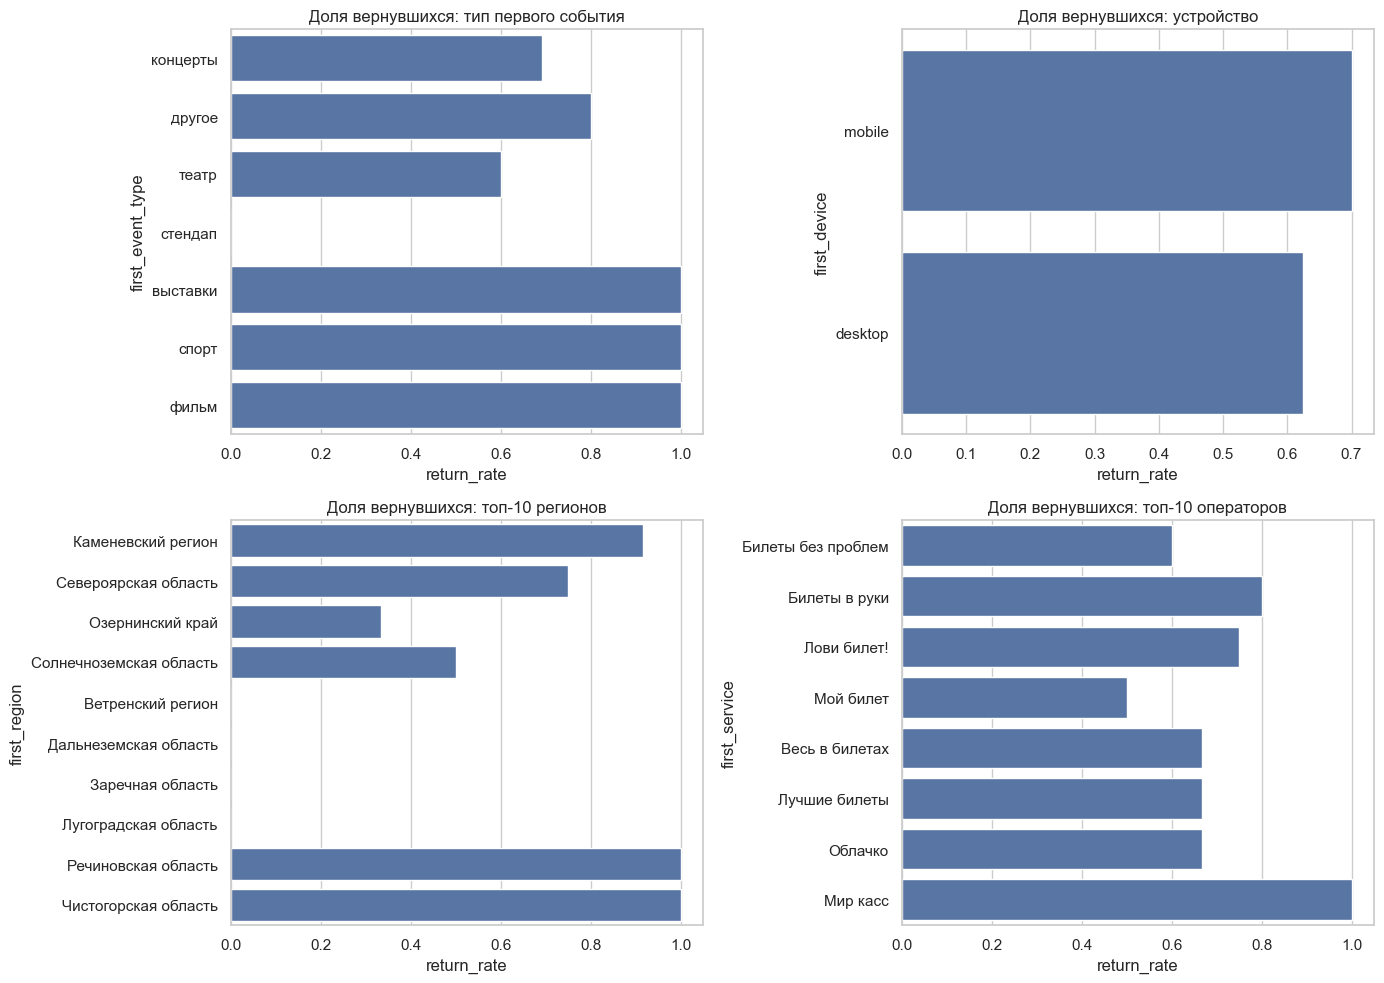

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=ret_event, x="return_rate", y="first_event_type", ax=axes[0, 0])
axes[0, 0].set_title("Доля вернувшихся: тип первого события")

sns.barplot(data=ret_device, x="return_rate", y="first_device", ax=axes[0, 1])
axes[0, 1].set_title("Доля вернувшихся: устройство")

sns.barplot(data=ret_region, x="return_rate", y="first_region", ax=axes[1, 0])
axes[1, 0].set_title("Доля вернувшихся: топ-10 регионов")

sns.barplot(data=ret_service, x="return_rate", y="first_service", ax=axes[1, 1])
axes[1, 1].set_title("Доля вернувшихся: топ-10 операторов")

plt.tight_layout()

Промежуточный вывод: рассчитаны доли повторных заказов по сегментам первого заказа.
На графиках видно, что доли возврата заметно отличаются между сегментами. При интерпретации нужно учитывать размер сегментов: для мелких групп (десятки пользователей или меньше) доли нестабильны.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [18]:
# Гипотеза 1: спорт vs концерты

def normalize_text(s):
    return str(s).strip().lower()

profile_df["first_event_type_norm"] = profile_df["first_event_type"].map(normalize_text)

sport_mask = profile_df["first_event_type_norm"].str.contains("спорт", na=False)
concert_mask = profile_df["first_event_type_norm"].str.contains("концерт", na=False)

sport_rate = profile_df.loc[sport_mask, "is_two"].mean()
concert_rate = profile_df.loc[concert_mask, "is_two"].mean()

print(f"Доля возврата (спорт): {sport_rate:.2%}")
print(f"Доля возврата (концерты): {concert_rate:.2%}")

# Гипотеза 2: топ-регионы vs остальные

region_counts = profile_df["first_region"].value_counts()
top_regions = region_counts.head(10).index

profile_df["is_top_region"] = profile_df["first_region"].isin(top_regions)

ret_top = profile_df.loc[profile_df["is_top_region"], "is_two"].mean()
ret_other = profile_df.loc[~profile_df["is_top_region"], "is_two"].mean()

print(f"Доля возврата (топ-10 регионов): {ret_top:.2%}")
print(f"Доля возврата (остальные регионы): {ret_other:.2%}")

Доля возврата (спорт): 100.00%
Доля возврата (концерты): 69.23%
Доля возврата (топ-10 регионов): 66.67%
Доля возврата (остальные регионы): 100.00%


In [19]:
print("Размер сегмента спорт:", sport_mask.sum())
print("Размер сегмента концерты:", concert_mask.sum())
print("Пользователей в топ-регионах:", profile_df["is_top_region"].sum())
print("Пользователей в остальных регионах:", (~profile_df["is_top_region"]).sum())

Размер сегмента спорт: 1
Размер сегмента концерты: 13
Пользователей в топ-регионах: 27
Пользователей в остальных регионах: 1


Промежуточный вывод: проверены продуктовые гипотезы по доле возврата в сегментах спорта/концертов
и в наиболее активных регионах. Итоговые выводы зависят от рассчитанных долей и размеров сегментов.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


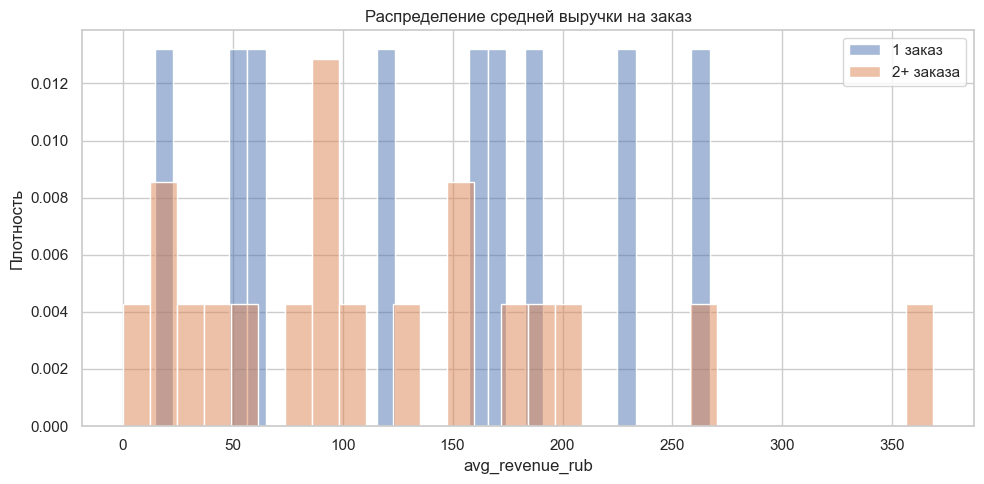

In [20]:
one_order = profile_df[profile_df["total_orders"] == 1]["avg_revenue_rub"]
returned = profile_df[profile_df["total_orders"] >= 2]["avg_revenue_rub"]

plt.figure(figsize=(10, 5))
sns.histplot(one_order, bins=30, alpha=0.5, label="1 заказ", stat="density")
sns.histplot(returned, bins=30, alpha=0.5, label="2+ заказа", stat="density")
plt.legend()
plt.title("Распределение средней выручки на заказ")
plt.xlabel("avg_revenue_rub")
plt.ylabel("Плотность")
plt.tight_layout()

In [21]:
pd.concat([
    one_order.describe().to_frame("1 заказ"),
    returned.describe().to_frame("2+ заказа")
], axis=1)

,1 заказ,2+ заказа
count,9.000000,19.000000
mean,140.732414,119.169225
std,85.063333,94.162729
min,14.514253,0.000000
25%,64.332728,48.230726
50%,158.571897,98.193482
75%,187.235055,168.057619
max,267.022039,368.674972


Промежуточный вывод: сравнили распределения средней выручки на заказ для пользователей с одним заказом
и для вернувшихся. На гистограммах видно, что распределения частично перекрываются, но у вернувшихся пользователей заметна концентрация в более высоких значениях средней выручки. Это может указывать на связь более «дорогих» заказов с повторными покупками.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


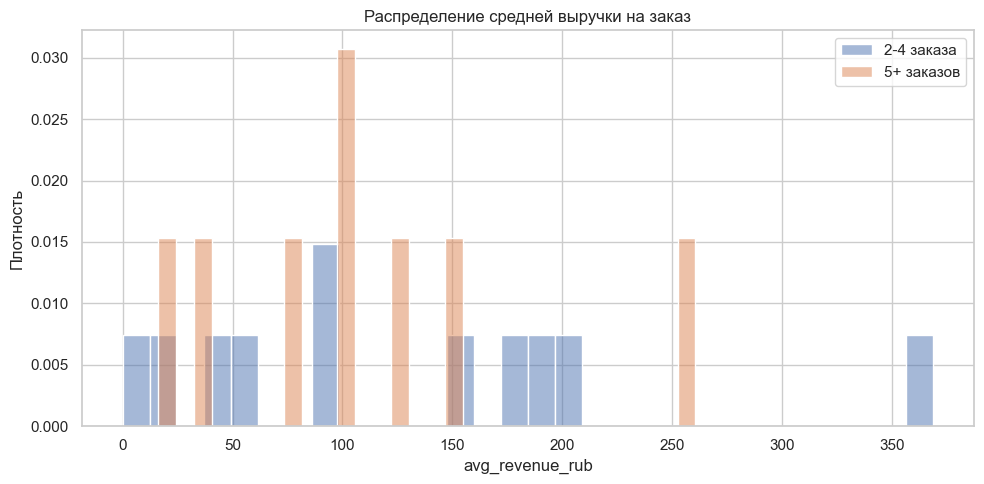

In [22]:
group_2_4 = profile_df[(profile_df["total_orders"] >= 2) & (profile_df["total_orders"] <= 4)]["avg_revenue_rub"]
group_5_plus = profile_df[profile_df["total_orders"] >= 5]["avg_revenue_rub"]

plt.figure(figsize=(10, 5))
sns.histplot(group_2_4, bins=30, alpha=0.5, label="2-4 заказа", stat="density")
sns.histplot(group_5_plus, bins=30, alpha=0.5, label="5+ заказов", stat="density")
plt.legend()
plt.title("Распределение средней выручки на заказ")
plt.xlabel("avg_revenue_rub")
plt.ylabel("Плотность")
plt.tight_layout()

In [23]:
pd.concat([
    group_2_4.describe().to_frame("2-4 заказа"),
    group_5_plus.describe().to_frame("5+ заказов")
], axis=1)

,2-4 заказа,5+ заказов
count,11.000000,8.000000
mean,126.789365,108.691533
std,108.537964,75.854434
min,0.000000,16.243362
25%,48.230726,69.308752
50%,89.803105,99.485263
75%,189.182289,134.737196
max,368.674972,260.486693


Промежуточный вывод: оценили различия средней выручки на заказ между группами 2–4 заказа и 5+ заказов.
По распределениям нет резкого разделения, но группа с 5+ заказами в среднем имеет более плотное ядро в схожих или чуть более высоких значениях выручки. Это может отражать более стабильный «чек» у лояльных пользователей.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

/var/folders/vn/l89_nzgs7rldqwp3dpz8dhxm0000gn/T/ipykernel_59236/4196382560.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_stats = profile_df.groupby("tickets_segment").agg(


,tickets_segment,users,return_rate
0,1-2,8,0.500000
1,2-3,15,0.866667
2,3-5,5,0.400000
3,5+,0,NaN


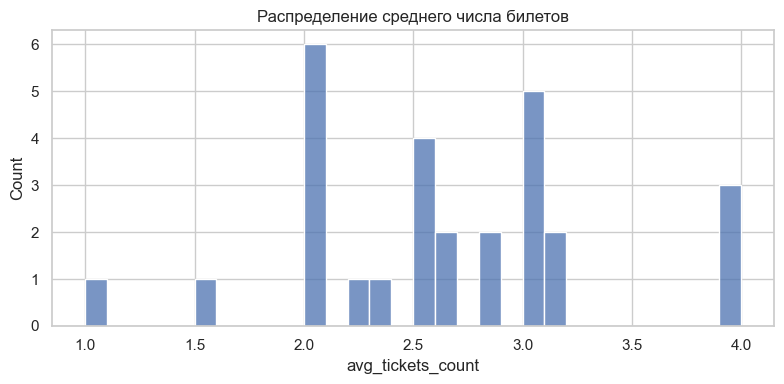

In [24]:
plt.figure(figsize=(8, 4))
sns.histplot(profile_df["avg_tickets_count"], bins=30)
plt.title("Распределение среднего числа билетов")
plt.xlabel("avg_tickets_count")
plt.tight_layout()

bins = [1, 2, 3, 5, np.inf]
labels = ["1-2", "2-3", "3-5", "5+"]

profile_df["tickets_segment"] = pd.cut(
    profile_df["avg_tickets_count"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True,
)

segment_stats = profile_df.groupby("tickets_segment").agg(
    users=("user_id", "count"),
    return_rate=("is_two", "mean"),
).reset_index()

segment_stats

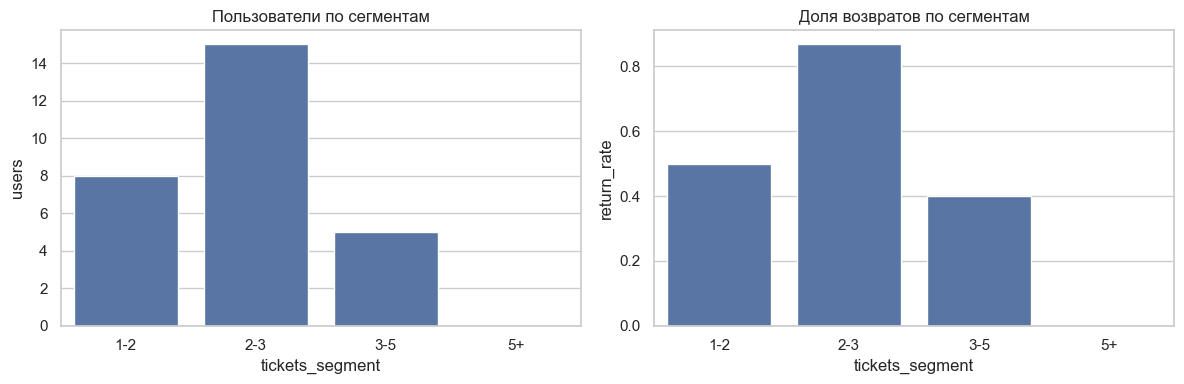

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=segment_stats, x="tickets_segment", y="users", ax=axes[0])
axes[0].set_title("Пользователи по сегментам")

sns.barplot(data=segment_stats, x="tickets_segment", y="return_rate", ax=axes[1])
axes[1].set_title("Доля возвратов по сегментам")

plt.tight_layout()

Промежуточный вывод: сегментация по среднему числу билетов показывает, что самая высокая доля возврата
в группе 2–3 билета (≈86.7%, n=15). Для 1–2 билетов доля ниже (≈50%, n=8), а для 3–5 билетов — ещё ниже (≈40%, n=5).
То есть умеренный размер заказа может быть связан с большей вероятностью повторной покупки.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [26]:
weekday_map = {
    0: "Пн",
    1: "Вт",
    2: "Ср",
    3: "Чт",
    4: "Пт",
    5: "Сб",
    6: "Вс",
}

profile_df["first_order_weekday"] = profile_df["first_order_dt"].dt.weekday.map(weekday_map)

weekday_stats = profile_df.groupby("first_order_weekday").agg(
    users=("user_id", "count"),
    return_rate=("is_two", "mean"),
).reindex(["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]).reset_index()

weekday_stats

,first_order_weekday,users,return_rate
0,Пн,3,0.666667
1,Вт,4,0.000000
2,Ср,4,1.000000
3,Чт,4,0.750000
4,Пт,2,1.000000
5,Сб,6,0.666667
6,Вс,5,0.800000


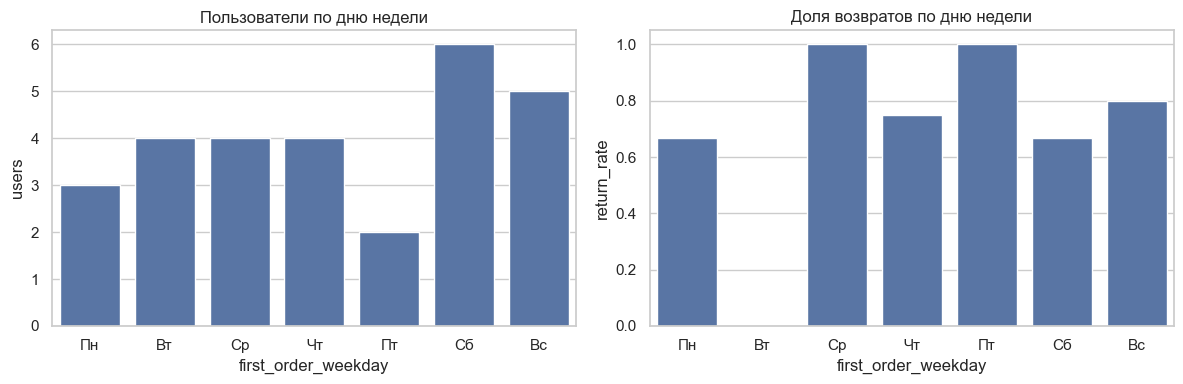

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=weekday_stats, x="first_order_weekday", y="users", ax=axes[0])
axes[0].set_title("Пользователи по дню недели")

sns.barplot(data=weekday_stats, x="first_order_weekday", y="return_rate", ax=axes[1])
axes[1].set_title("Доля возвратов по дню недели")

plt.tight_layout()

Промежуточный вывод: по дням недели видны колебания доли возврата (например, Ср — 100%, Вт — 0%),
но размеры групп небольшие (n=2–6). Поэтому эффект дня недели нельзя считать устойчивым без большей выборки.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [28]:
avg_days_2_4 = profile_df[(profile_df["total_orders"] >= 2) & (profile_df["total_orders"] <= 4)]["avg_days_between"]
avg_days_5_plus = profile_df[profile_df["total_orders"] >= 5]["avg_days_between"]

pd.concat([
    avg_days_2_4.describe().to_frame("2-4 заказа"),
    avg_days_5_plus.describe().to_frame("5+ заказов")
], axis=1)

,2-4 заказа,5+ заказов
count,11.000000,8.000000
mean,22.439394,11.294506
std,20.005037,8.681405
min,0.000000,1.333333
25%,4.500000,7.614706
50%,14.000000,9.701389
75%,37.833333,11.895833
max,51.000000,29.400000


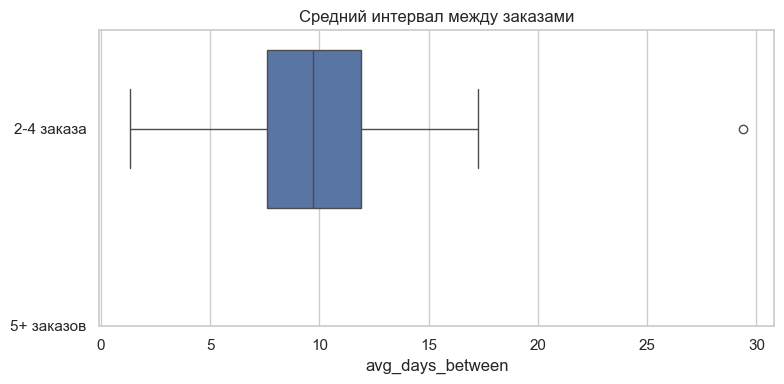

In [29]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=[avg_days_2_4.dropna(), avg_days_5_plus.dropna()], orient="h")
plt.yticks([0, 1], ["2-4 заказа", "5+ заказов"])
plt.title("Средний интервал между заказами")
plt.xlabel("avg_days_between")
plt.tight_layout()

Промежуточный вывод: у пользователей с 5+ заказами средний интервал между покупками ниже
(≈11.3 дня), чем у группы 2–4 заказа (≈22.4 дня). Это говорит о более регулярном поведении у
лояльных клиентов и может быть использовано для настройки триггерных коммуникаций.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [30]:
import phik

# Сегментация по числу заказов
profile_df["total_orders_segment"] = pd.cut(
    profile_df["total_orders"],
    bins=[0, 1, 4, np.inf],
    labels=["1", "2-4", "5+"],
)

corr_cols = [
    "total_orders",
    "total_orders_segment",
    "avg_revenue_rub",
    "avg_tickets_count",
    "avg_days_between",
    "first_device",
    "first_region",
    "first_service",
    "first_event_type",
    "first_order_weekday",
]

corr_df = profile_df[corr_cols].copy()

# phi_k чувствителен к пропускам, поэтому заполним их
for col in corr_df.columns:
    if corr_df[col].dtype.kind in "biufc":
        corr_df[col] = corr_df[col].fillna(corr_df[col].median())
    else:
        corr_df[col] = corr_df[col].astype("string").fillna("unknown")

phik_matrix = corr_df.phik_matrix(interval_cols=[
    "total_orders",
    "avg_revenue_rub",
    "avg_tickets_count",
    "avg_days_between",
])

phik_matrix

,total_orders,total_orders_segment,avg_revenue_rub,avg_tickets_count,avg_days_between,first_device,first_region,first_service,first_event_type,first_order_weekday
total_orders,1.000000,0.672239,0.000000,0.272605,0.505073,0.000000,0.000000,0.000000,0.513456,0.434620
total_orders_segment,0.672239,1.000000,0.000000,0.661075,0.664831,0.000000,0.357861,0.000000,0.346986,0.552460
avg_revenue_rub,0.000000,0.000000,1.000000,0.479871,0.000000,0.000000,0.734703,0.308023,0.000000,0.000000
avg_tickets_count,0.272605,0.661075,0.479871,1.000000,0.000000,0.099313,0.433790,0.000000,0.458043,0.000000
avg_days_between,0.505073,0.664831,0.000000,0.000000,1.000000,0.000000,0.000000,0.351055,0.525178,0.000000
first_device,0.000000,0.000000,0.000000,0.099313,0.000000,1.000000,0.000000,0.555026,0.188190,0.366043
first_region,0.000000,0.357861,0.734703,0.433790,0.000000,0.000000,1.000000,0.532554,0.000000,0.311070
first_service,0.000000,0.000000,0.308023,0.000000,0.351055,0.555026,0.532554,1.000000,0.349556,0.000000
first_event_type,0.513456,0.346986,0.000000,0.458043,0.525178,0.188190,0.000000,0.349556,1.000000,0.612105
first_order_weekday,0.434620,0.552460,0.000000,0.000000,0.000000,0.366043,0.311070,0.000000,0.612105,1.000000


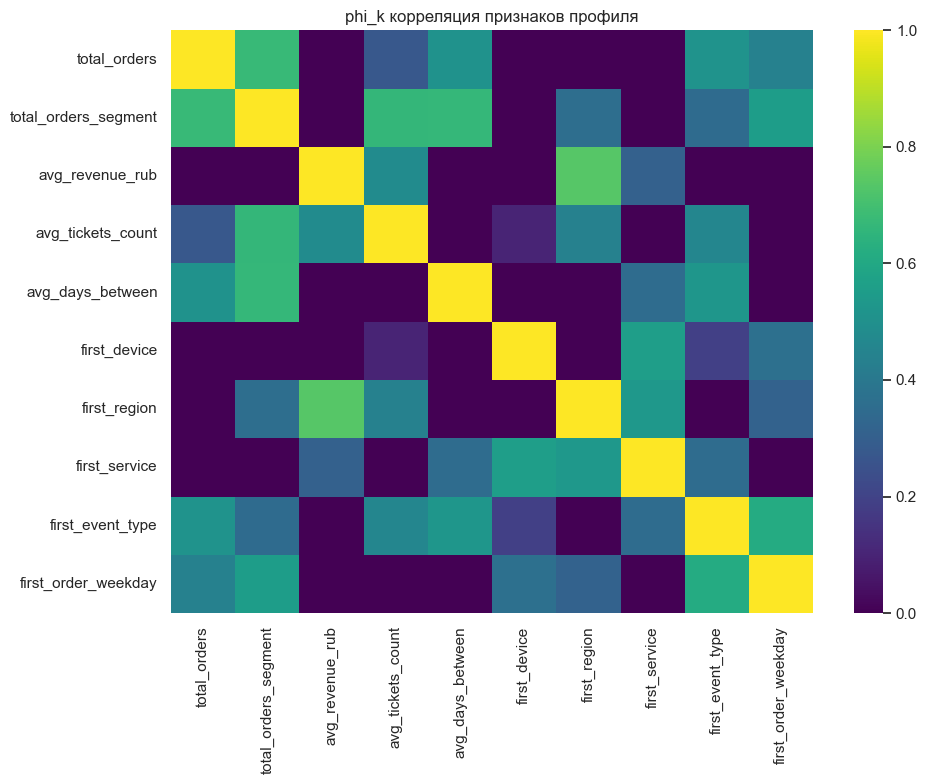

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix, cmap="viridis", annot=False)
plt.title("phi_k корреляция признаков профиля")
plt.tight_layout()

Промежуточный вывод: тепловая карта `phi_k` показывает, что сильнее всего с количеством заказов связаны
показатели, отражающие поведение пользователя (например, сегмент по числу заказов, средний интервал и
среднее число билетов). Связи с категориальными признаками первого заказа выражены слабее, что также
может быть следствием небольшой выборки.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

### Общий вывод и рекомендации

**Данные и подготовка**
- Заказы выгружены из БД, даты приведены к формату datetime.
- Выручка конвертирована в рубли (`revenue_rub`) по курсу тенге.
- Выбросы по `revenue_rub` удалены по 99-му перцентилю (доля удалённых: 1.00%).
- Интервалы между покупками приведены к дням, отрицательные значения исключены.

**Ключевые факты**
- Пользователей в выборке: 29 (выборка небольшая, выводы чувствительны к размерам сегментов).
- Средняя выручка с заказа: 103.07 RUB.
- Доля пользователей с 2+ заказами: 68.97%, с 5+ заказами: 31.03%.
- Средний интервал между покупками (для пользователей с 2+ заказами): 16.87 дня.

**Результаты анализа**
- Наиболее частый тип первого события: концерты (13 пользователей, доля 46.43%).
- Наиболее частый регион первого заказа: Каменевский регион (12 пользователей, доля 42.86%).
- Наиболее частый оператор: Билеты без проблем (5 пользователей, доля 17.86%).
- Гипотеза 1 (спорт vs концерты): 100% (n=1) против 69.23% (n=13).
- Гипотеза 2 (топ‑10 регионов vs остальные): 66.67% (n=27) против 100% (n=1).
- По числу билетов в среднем заказе: 1–2 — 50.00% (n=8), 2–3 — 86.67% (n=15), 3–5 — 40.00% (n=5).
- День недели первого заказа: лучший — Ср (100%, n=4), худший — Вт (0%, n=4).
- Средний интервал между покупками: 2–4 заказа — 22.44 дня (n=11), 5+ заказов — 11.29 дня (n=8).

**Рекомендации для маркетинга**
- Делать ставку на сегменты с высокой долей возврата, но учитывать малые размеры некоторых сегментов (n=1–5).
- Для пользователей с 5+ заказами усиливать коммуникации в первые 1–2 недели после заказа.
- Сегмент 2–3 билета показывает более высокую долю возврата; для 1–2 билетов протестировать доп. стимулы повторной покупки.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Ссылка на репозиторий:** https://github.com/gopapagri/afisha_loyalty